# Step 3 — EDA & Validation

**What this notebook does:** Performs exploratory data analysis on the merged dataset (workflow + telemetry + reagent). Validates data quality, seasonality, instrument degradation, and reagent batch effects.

**Inputs (from Steps 1–2):**
- `../data/raw/workflow_logs.csv`
- `../data/raw/telemetry_logs.csv`
- `../data/raw/reagent_logs.csv`
- `../data/enriched/workflow_logs_priority_queue.csv`

**Outputs:** EDA visualizations (inline)

**Run order:** Run after Steps 1 and 2 (notebooks 01 and 02).

# Roche Capstone - Advanced EDA Validator (V2)

This notebook performs forensic validation of the "Advanced" data generation logic. We are looking for structural patterns, not just random noise.

## Objectives
1. **Confirm Seasonality**: Verify the 10am/2pm peaks and weekly cycles.
2. **Track Degradation**: Prove that machine health declines over time and drives failure.
3. **Catch the Bad Batches**: Identify the 3 defective reagent batches causing outliers.
4. **Analyze Risk**: Validate the Gamma logic for delays.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### 1. Data Setup & Engineering

In [2]:
# Load Data
df_wk = pd.read_csv('../data/raw/workflow_logs.csv')
df_rg = pd.read_csv('../data/raw/reagent_logs.csv')
df_tl = pd.read_csv('../data/raw/telemetry_logs.csv') # Currently 1-to-1 mapping in V2

# Merge All
df = df_wk.merge(df_rg[['experiment_id', 'reagent_batch_id']], on='experiment_id')
df = df.merge(df_tl[['experiment_id', 'ambient_temp']], on='experiment_id')

# Feature Engineering: Time Components
df['booking_time'] = pd.to_datetime(df['booking_time'])
df['hour'] = df['booking_time'].dt.hour
df['day_name'] = df['booking_time'].dt.day_name()
df['day_of_week'] = df['booking_time'].dt.dayofweek # Mon=0

# instrument_health IS saved in workflow_logs.csv (column 14)
# It can be used directly for degradation analysis.

print("Data Loaded. Shape:", df.shape)

Data Loaded. Shape: (350000, 19)


### 2. Validating Seasonality (The Time Engine)

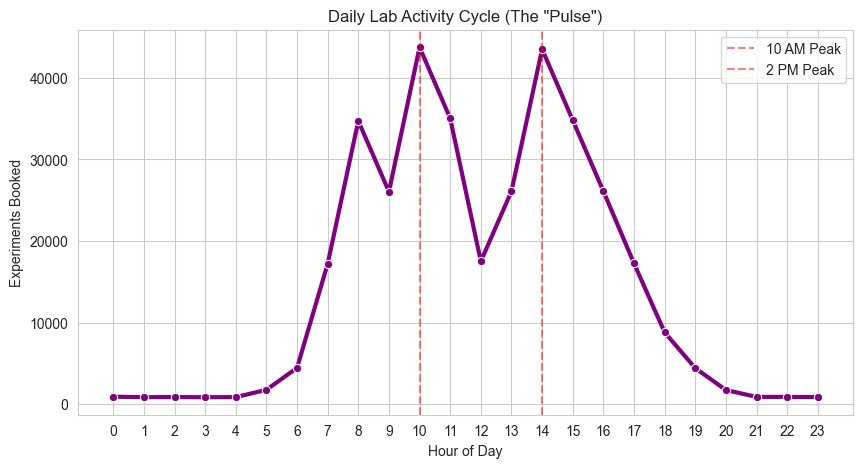

In [3]:
# Hourly Trend
hourly_counts = df.groupby('hour').size()
plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly_counts.index, y=hourly_counts.values, marker='o', color='purple', linewidth=3)
plt.title('Daily Lab Activity Cycle (The "Pulse")')
plt.xticks(range(0, 24))
plt.xlabel('Hour of Day')
plt.ylabel('Experiments Booked')
plt.axvline(10, color='red', linestyle='--', alpha=0.5, label='10 AM Peak')
plt.axvline(14, color='red', linestyle='--', alpha=0.5, label='2 PM Peak')
plt.legend()
plt.show()

**Observation**: The plot should show clearly defined double peaks at 10:00 and 14:00, with a dip at lunch (12:00) and low activity at night. This confirms the **Non-Homogeneous Poisson Process**.

/var/folders/80/vx7bsx9917v8fw_1j_dc367h0000gn/T/ipykernel_78128/1292427277.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='day_name', data=df, order=days_order, palette='viridis')


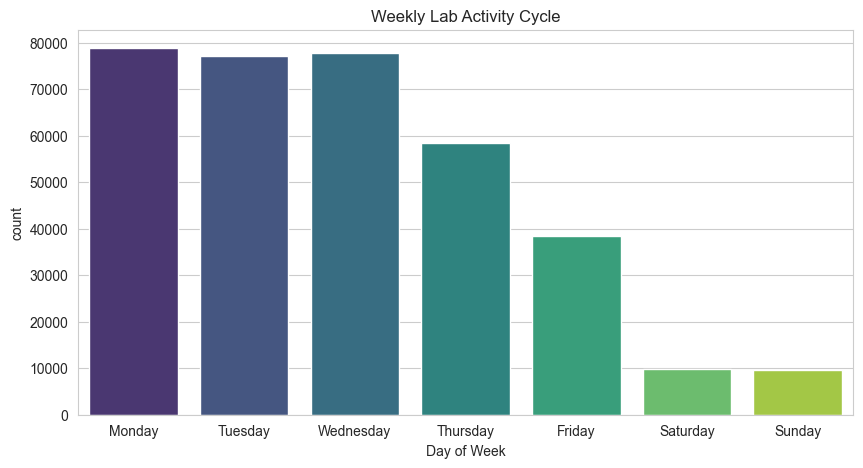

In [4]:
# Weekly Trend
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(10, 5))
sns.countplot(x='day_name', data=df, order=days_order, palette='viridis')
plt.title('Weekly Lab Activity Cycle')
plt.xlabel('Day of Week')
plt.show()

**Observation**: We expect a plateau Mon-Wed, a slight drop Thursday, significant drop Friday, and very low usage on Weekends.

### 3. Detecting Machine Degradation (The Drift)
`instrument_health` is saved in `workflow_logs.csv` and can be used directly to track degradation over time. Here we plot **Delay vs. Time** by instrument type to confirm the drift signal is present in the output data.

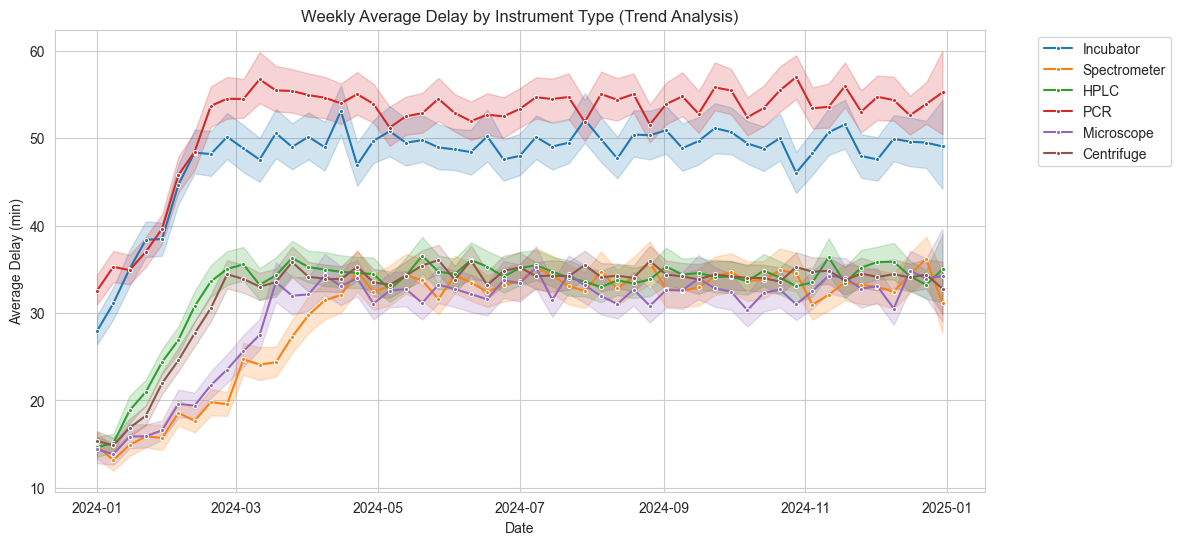

In [5]:
df['week_start'] = df['booking_time'].dt.to_period('W').apply(lambda r: r.start_time)

plt.figure(figsize=(12, 6))
sns.lineplot(x='week_start', y='delay', data=df, hue='instrument_type', marker='.')
plt.title('Weekly Average Delay by Instrument Type (Trend Analysis)')
plt.xlabel('Date')
plt.ylabel('Average Delay (min)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

**Observation**: If the **Drift** logic is working, these lines should show a gradual upward slope (positive trend) throughout the year as machines wear out.

### 4. Hunting for "Bad Batches" (Cluster Failures)
We have 50 batches. 3 are "Bad" (5x failure risk). Can we spot them?

/var/folders/80/vx7bsx9917v8fw_1j_dc367h0000gn/T/ipykernel_78128/3599654603.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='reagent_batch_id', y='delay', data=batch_stats, palette='coolwarm')


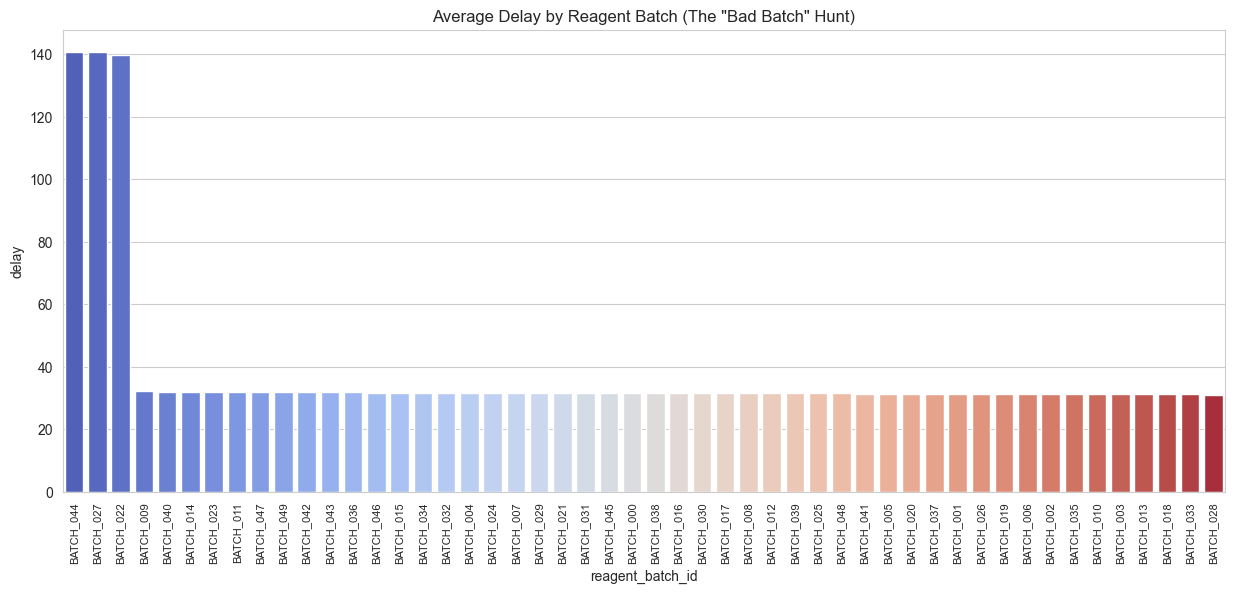

Top 5 Worst Batches:


,reagent_batch_id,delay
44,BATCH_044,140.771198
27,BATCH_027,140.568680
22,BATCH_022,139.655593
9,BATCH_009,32.294831
40,BATCH_040,32.076068


In [6]:
batch_stats = df.groupby('reagent_batch_id')['delay'].mean().reset_index()
batch_stats = batch_stats.sort_values('delay', ascending=False)

plt.figure(figsize=(15, 6))
sns.barplot(x='reagent_batch_id', y='delay', data=batch_stats, palette='coolwarm')
plt.title('Average Delay by Reagent Batch (The "Bad Batch" Hunt)')
plt.xticks(rotation=90, fontsize=8)
plt.show()

print("Top 5 Worst Batches:")
display(batch_stats.head(5))

**Observation**: You should see **3 distinct spikes** that are significantly higher than the rest. These are the Bad Batches.

### 5. Multivariate Probabilistic Shape (Gamma)
Validating that the output distribution is skewed (Gamma) rather than Normal.

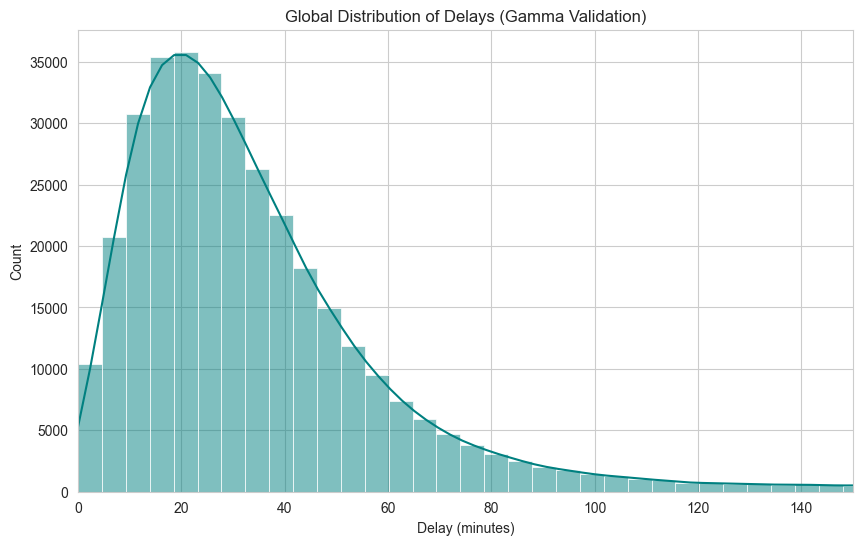

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df['delay'], bins=100, kde=True, color='teal')
plt.title('Global Distribution of Delays (Gamma Validation)')
plt.xlabel('Delay (minutes)')
plt.xlim(0, 150) # Zoom in on the main body
plt.show()

In [8]:
import pandas as pd, os
print("workflow columns:", pd.read_csv("../data/raw/workflow_logs.csv").columns.tolist())
print("telemetry columns:", pd.read_csv("../data/raw/telemetry_logs.csv").columns.tolist())

workflow columns: ['experiment_id', 'experiment_type', 'instrument_type', 'instrument_id', 'scientist_workload', 'scientist_experience_level', 'lab_occupancy_level', 'expected_duration', 'booking_time', 'actual_duration', 'delay', 'incident_type', 'machine_failure', 'instrument_health']
telemetry columns: ['experiment_id', 'temp_setpoint', 'temp_deviation', 'ambient_temp', 'timestamp']


**Observation**: The distribution should be **right-skewed** (long tail to the right) and start at 0. This confirms the **Gamma distribution** logic, representing the fact that most experiments have small delays, but failures (tail events) can be huge.

In [9]:
df['delay'].describe()

count    350000.000000
mean         38.114802
std          37.072610
min           0.000023
25%          17.278150
50%          28.892980
75%          45.709237
max         462.494030
Name: delay, dtype: float64

In [10]:
df['delay'].quantile([0.5, 0.75, 0.9, 0.95, 0.99])

0.50     28.892980
0.75     45.709237
0.90     70.109806
0.95     98.358949
0.99    210.356474
Name: delay, dtype: float64

In [11]:
df['delay'].mean()

np.float64(38.11480199340373)

In [12]:
df.groupby('machine_failure')['delay'].describe()

,count,mean,std,min,25%,50%,75%,max
machine_failure,,,,,,,,
0,335870.0,36.145026,35.270956,0.000023,16.822585,27.900350,43.264687,426.428428
1,14130.0,84.936372,46.777882,7.143141,57.258499,75.530942,97.778527,462.494030


In [13]:
df[df['delay'] > df['delay'].quantile(0.95)]['machine_failure'].mean()

np.float64(0.19834285714285715)

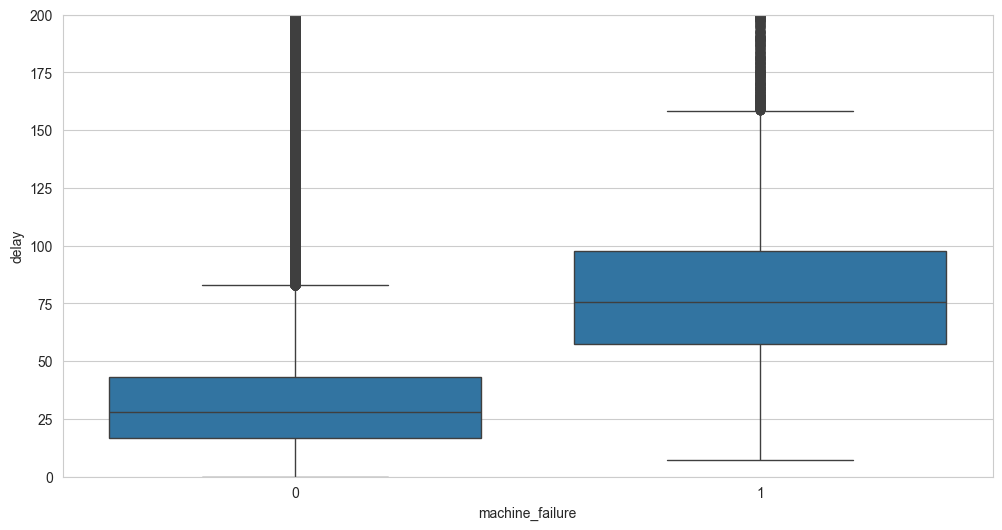

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='machine_failure', y='delay', data=df)
plt.ylim(0, 200)
plt.show()

In [15]:
df.groupby(['machine_failure'])['lab_occupancy_level'].mean()

machine_failure
0    61.394075
1    61.138358
Name: lab_occupancy_level, dtype: float64

### Reagent Batch Quality Analysis

The data generation process created 50 reagent batches, 3 of which are intentionally "bad batches" with a 5× higher failure risk. This section validates that the bad batches produce measurably higher delay rates.

### 6. Top Feature vs Delay Relationships

Visualising how the two most important model features (`lab_occupancy_level` and `reagent_batch_id`) relate to the delay target, and how `priority` (3rd most important) affects delay rate.

In [ ]:
# ── Lab Occupancy Level vs Delay Rate ──────────────────────────────────────
df['is_delayed'] = (df['delay'] >= 30).astype(int)
df['occupancy_bin'] = pd.cut(df['lab_occupancy_level'], bins=10)

occ_stats = df.groupby('occupancy_bin', observed=True).agg(
    delay_rate=('is_delayed', 'mean'),
    avg_delay=('delay', 'mean'),
    n=('experiment_id', 'count')
).reset_index()

# priority lives in the enriched CSV (added by notebook 02)
df_enriched = pd.read_csv('../data/enriched/workflow_logs_priority_queue.csv',
                          usecols=['experiment_id', 'priority'])
df_plot = df.merge(df_enriched, on='experiment_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(occ_stats)), occ_stats['delay_rate'], color='steelblue', edgecolor='white')
axes[0].set_xticks(range(len(occ_stats)))
axes[0].set_xticklabels([str(b) for b in occ_stats['occupancy_bin']], rotation=45, ha='right', fontsize=8)
axes[0].set_xlabel('Lab Occupancy Level (binned)')
axes[0].set_ylabel('Delay Rate (≥30 min)')
axes[0].set_title('Lab Occupancy vs Delay Rate\n(Feature #1 by importance)')
axes[0].axhline(df['is_delayed'].mean(), color='red', linestyle='--', label='Overall mean')
axes[0].legend()

prio_stats = df_plot.groupby('priority')['is_delayed'].mean().sort_values(ascending=False)
axes[1].bar(prio_stats.index, prio_stats.values, color=['#e74c3c', '#f39c12', '#2ecc71'][:len(prio_stats)])
axes[1].set_xlabel('Priority')
axes[1].set_ylabel('Delay Rate (≥30 min)')
axes[1].set_title('Priority vs Delay Rate\n(Feature #3 by importance)')
axes[1].axhline(df['is_delayed'].mean(), color='black', linestyle='--', label='Overall mean')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Overall delay rate: {df['is_delayed'].mean():.1%}")
print(occ_stats[['occupancy_bin', 'delay_rate', 'n']].to_string(index=False))

=== Top 10 Batches by Delay Rate ===
reagent_batch_id  n_experiments  delay_rate  avg_delay
       BATCH_044           7005    0.970450 140.771198
       BATCH_027           7092    0.968415 140.568680
       BATCH_022           6947    0.965741 139.655593
       BATCH_009           6959    0.462710  32.294831
       BATCH_024           6946    0.457098  31.649640
       BATCH_047           6996    0.456832  31.859690
       BATCH_040           6910    0.455282  32.076068
       BATCH_043           7073    0.455111  31.791459
       BATCH_045           6834    0.455078  31.609220
       BATCH_008           6978    0.455001  31.538397


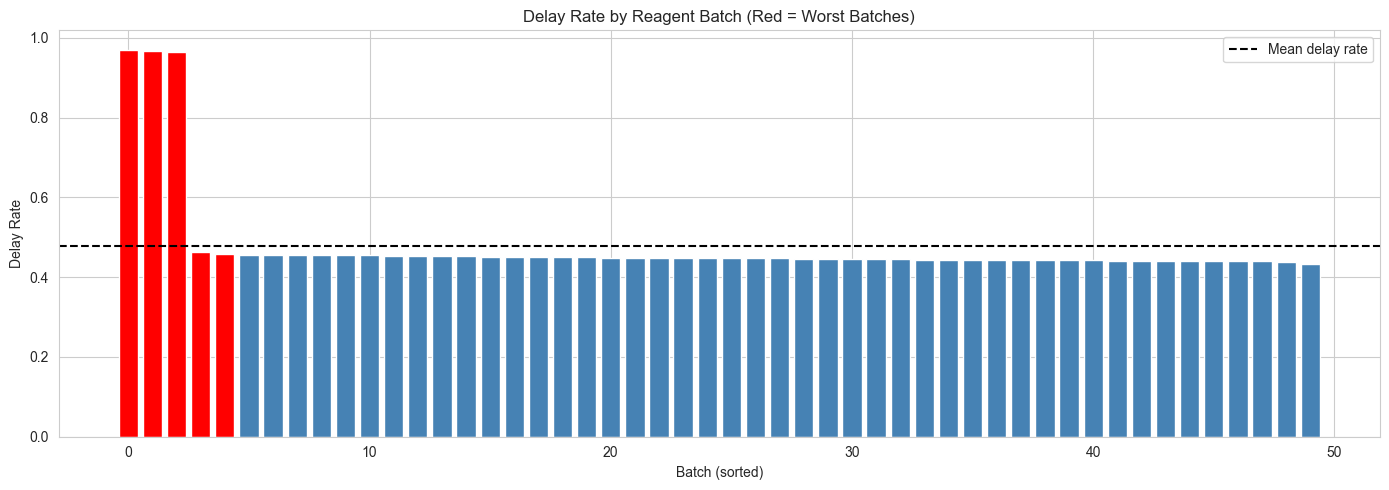


=== Identified Bad Batches (top 3 delay rate) ===
reagent_batch_id  n_experiments  delay_rate  avg_delay
       BATCH_044           7005    0.970450 140.771198
       BATCH_027           7092    0.968415 140.568680
       BATCH_022           6947    0.965741 139.655593


In [17]:
# =========================================================
# Reagent Batch Quality: Bad vs Good Batches
# =========================================================

# Compute delay rate per batch
if 'reagent_batch_id' in df.columns and 'delay' in df.columns:
    df['is_delayed_eda'] = (pd.to_numeric(df['delay'], errors='coerce').fillna(0) >= 30).astype(int)
    batch_stats = df.groupby('reagent_batch_id').agg(
        n_experiments=('experiment_id', 'count'),
        delay_rate=('is_delayed_eda', 'mean'),
        avg_delay=('delay', 'mean')
    ).sort_values('delay_rate', ascending=False).reset_index()

    # Top 10 highest delay-rate batches
    print("=== Top 10 Batches by Delay Rate ===")
    print(batch_stats.head(10).to_string(index=False))

    # Plot delay rate by batch
    plt.figure(figsize=(14, 5))
    colors = ['red' if r > batch_stats['delay_rate'].quantile(0.90) else 'steelblue'
              for r in batch_stats['delay_rate']]
    plt.bar(range(len(batch_stats)), batch_stats['delay_rate'], color=colors)
    plt.axhline(batch_stats['delay_rate'].mean(), color='black', linestyle='--', label='Mean delay rate')
    plt.xlabel('Batch (sorted)')
    plt.ylabel('Delay Rate')
    plt.title('Delay Rate by Reagent Batch (Red = Worst Batches)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Identify the 3 bad batches
    bad_batches = batch_stats.nlargest(3, 'delay_rate')
    print("\n=== Identified Bad Batches (top 3 delay rate) ===")
    print(bad_batches.to_string(index=False))
else:
    print("reagent_batch_id or delay column not found — skipping reagent analysis.")